In [1]:
import sys
sys.path.append(r"C:\Users\anind\OneDrive\Desktop\DL_Proj_Face_Emotion\src\models")

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
import os


from all_models import (
    Simple_CNN,
    ResNet_Custom,
    ResNet_Attention,
    VGG16_Custom,
    MobileNetCustom,
    CNN_Attention
)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [4]:
TRAIN_DIR = r"C:\Users\anind\OneDrive\Desktop\DL_Proj_Face_Emotion\data\processed\train"
VAL_DIR   = r"C:\Users\anind\OneDrive\Desktop\DL_Proj_Face_Emotion\data\processed\val"
TEST_DIR  = r"C:\Users\anind\OneDrive\Desktop\DL_Proj_Face_Emotion\data\processed\test"

In [5]:
train_transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((128,128)),

    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation((-10, 10)),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),

    transforms.ColorJitter(brightness=0.2, contrast=0.2),

    transforms.ToTensor(),

    transforms.RandomErasing(p=0.1),

    transforms.Normalize([0.5],[0.5])
])


val_transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5],[0.5])
])

In [6]:
train_data = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_data   = datasets.ImageFolder(VAL_DIR, transform=val_transform)
test_data  = datasets.ImageFolder(TEST_DIR, transform=val_transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=64)
test_loader  = DataLoader(test_data, batch_size=64)


In [7]:
import os

print("Train Exists:", os.path.exists(TRAIN_DIR))
print("Val Exists:", os.path.exists(VAL_DIR))
print("Test Exists:", os.path.exists(TEST_DIR))

Train Exists: True
Val Exists: True
Test Exists: True


In [8]:
models_dict = {
    "cnn": Simple_CNN(),
    "resnet": ResNet_Custom(),
    "vgg": VGG16_Custom(),
    "resnet_attention": ResNet_Attention(),
    "mobilenet": MobileNetCustom(),
    "cnn_attention": CNN_Attention() 
}

In [9]:
#Loss + Evolution
criterion = nn.CrossEntropyLoss()

def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for x,y in loader:
            x,y = x.to(device), y.to(device)
            out = model(x)
            _, pred = torch.max(out,1)
            correct += (pred==y).sum().item()
            total += y.size(0)

    return correct/total

In [10]:
# =========================
# Training Loop
# =========================
results = {}
history = {}
best_per_model = {}

global_best_acc = 0
global_best_model_name = None

EPOCHS = 50

for name, model in models_dict.items():

    print(f"\n🔷 Training: {name}")
    model = model.to(device)

    if name == "vgg":
        optimizer = optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-5)
    else:
        optimizer = optim.Adam(model.parameters(), lr=1.5e-3, weight_decay=1e-4)

    # Scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='max',
        patience=2,
        factor=0.3
    )

    train_acc_list = []
    val_acc_list = []
    loss_list = []

    best_val_acc_model = 0

    # Early Stopping variables
    early_stop_counter = 0
    EARLY_STOP_PATIENCE = 5

    for epoch in range(EPOCHS):

        model.train()
        correct, total = 0, 0
        running_loss = 0

        for x,y in train_loader:
            x,y = x.to(device), y.to(device)

            out = model(x)
            loss = criterion(out,y)

            optimizer.zero_grad()
            loss.backward()

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()

            running_loss += loss.item() * x.size(0)

            _, pred = torch.max(out,1)
            correct += (pred==y).sum().item()
            total += y.size(0)

        epoch_loss = running_loss / total
        train_acc = correct / total
        val_acc = evaluate(model, val_loader)

        # Scheduler step
        scheduler.step(val_acc)

        train_acc_list.append(train_acc)
        val_acc_list.append(val_acc)
        loss_list.append(epoch_loss)

        # Save best + Early stopping logic
        if val_acc > best_val_acc_model:
            best_val_acc_model = val_acc
            torch.save(model.state_dict(), f"models/{name}_best.pth")

            early_stop_counter = 0  # reset
        else:
            early_stop_counter += 1

        # Early stopping trigger
        if early_stop_counter >= EARLY_STOP_PATIENCE:
            print(f"Early stopping triggered for {name}")
            break

        print(f"{name} | Epoch {epoch+1} | Loss: {epoch_loss:.4f} | Train: {train_acc:.4f} | Val: {val_acc:.4f}")

    history[name] = {
        "train_acc": train_acc_list,
        "val_acc": val_acc_list,
        "loss": loss_list
    }

    best_per_model[name] = best_val_acc_model
    results[name] = best_val_acc_model

    if best_val_acc_model > global_best_acc:
        global_best_acc = best_val_acc_model
        global_best_model_name = name


🔷 Training: cnn
cnn | Epoch 1 | Loss: 4.1760 | Train: 0.2052 | Val: 0.2680
cnn | Epoch 2 | Loss: 1.9711 | Train: 0.2838 | Val: 0.3919
cnn | Epoch 3 | Loss: 1.7530 | Train: 0.3606 | Val: 0.4567
cnn | Epoch 4 | Loss: 1.6475 | Train: 0.3988 | Val: 0.4812
cnn | Epoch 5 | Loss: 1.5687 | Train: 0.4303 | Val: 0.5136
cnn | Epoch 6 | Loss: 1.5038 | Train: 0.4511 | Val: 0.5453
cnn | Epoch 7 | Loss: 1.4505 | Train: 0.4687 | Val: 0.5659
cnn | Epoch 8 | Loss: 1.3938 | Train: 0.4913 | Val: 0.5698
cnn | Epoch 9 | Loss: 1.3639 | Train: 0.5010 | Val: 0.5753
cnn | Epoch 10 | Loss: 1.3445 | Train: 0.5100 | Val: 0.5917
cnn | Epoch 11 | Loss: 1.3102 | Train: 0.5174 | Val: 0.5992
cnn | Epoch 12 | Loss: 1.2966 | Train: 0.5319 | Val: 0.6079
cnn | Epoch 13 | Loss: 1.2818 | Train: 0.5309 | Val: 0.6116
cnn | Epoch 14 | Loss: 1.2575 | Train: 0.5385 | Val: 0.6156
cnn | Epoch 15 | Loss: 1.2519 | Train: 0.5387 | Val: 0.6116
cnn | Epoch 16 | Loss: 1.2446 | Train: 0.5414 | Val: 0.6193
cnn | Epoch 17 | Loss: 1.2315 | 

In [11]:
# Print best accuracy per model
print("\nBest Accuracy Per Model:")
for k,v in best_per_model.items():
    print(f"{k}: {v:.4f}")

print("\nGlobal Best Model:", global_best_model_name)
print("Global Best Accuracy:", round(global_best_acc,4))


Best Accuracy Per Model:
cnn: 0.6872
resnet: 0.7658
vgg: 0.7658
resnet_attention: 0.7609
mobilenet: 0.7614
cnn_attention: 0.6162

Global Best Model: resnet
Global Best Accuracy: 0.7658


In [12]:
import shutil

shutil.copy(
    f"models/{global_best_model_name}_best.pth",
    "models/final_best_model.pth"
)

'models/final_best_model.pth'

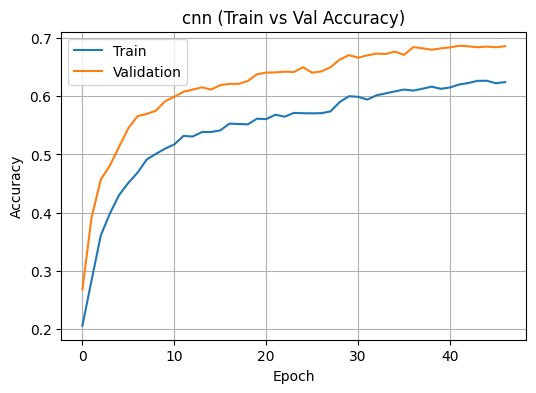

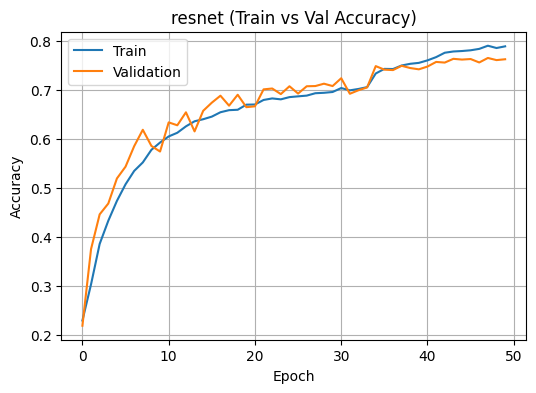

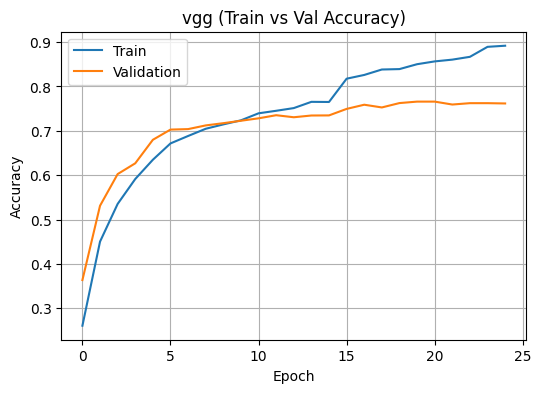

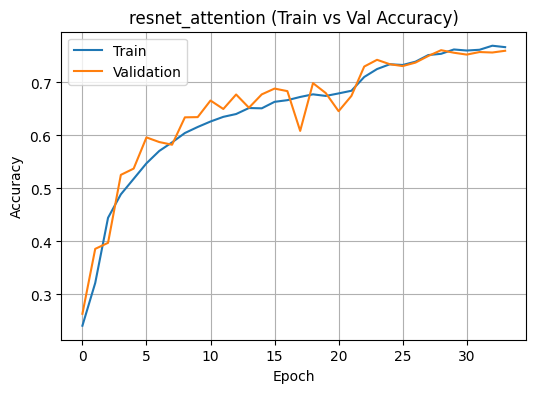

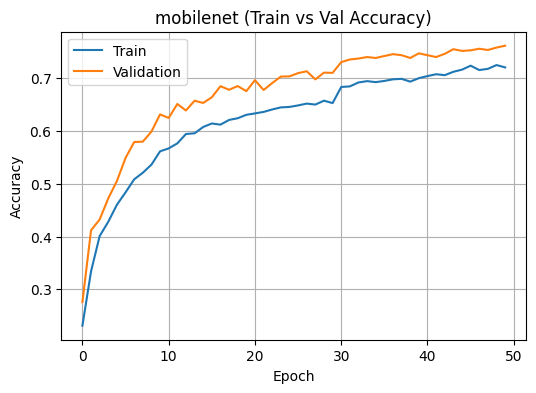

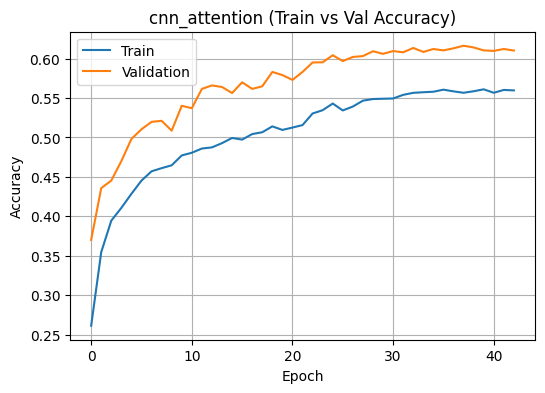

In [13]:
# Plot Train vs Validation accuracy for EACH model

for name in history:
    plt.figure(figsize=(6,4))

    plt.plot(history[name]["train_acc"], label="Train")
    plt.plot(history[name]["val_acc"], label="Validation")

    plt.title(f"{name} (Train vs Val Accuracy)")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid()

    plt.show()

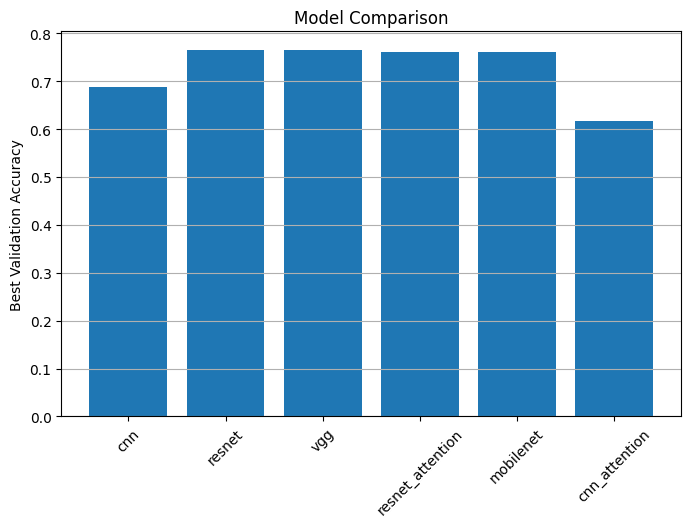

In [14]:
# Compare all models (best validation accuracy)

names = list(best_per_model.keys())
values = list(best_per_model.values())

plt.figure(figsize=(8,5))

plt.bar(names, values)
plt.xticks(rotation=45)
plt.ylabel("Best Validation Accuracy")
plt.title("Model Comparison")

plt.grid(axis='y')
plt.show()

In [15]:
# Load global best model and test

best_model = models_dict[global_best_model_name]
best_model.load_state_dict(torch.load(f"models/{global_best_model_name}_best.pth"))
best_model = best_model.to(device)

test_acc = evaluate(best_model, test_loader)

print("\n🏆 Best Model:", global_best_model_name)
print("✅ Test Accuracy:", round(test_acc*100, 2), "%")


🏆 Best Model: resnet
✅ Test Accuracy: 77.01 %


In [16]:
best_model = models_dict[global_best_model_name]
best_model.load_state_dict(torch.load(f"models/{global_best_model_name}_best.pth"))
best_model = best_model.to(device)

test_acc = evaluate(best_model, test_loader)

In [17]:
all_preds = []
all_labels = []

best_model.eval()

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        y = y.to(device)

        outputs = best_model(x)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

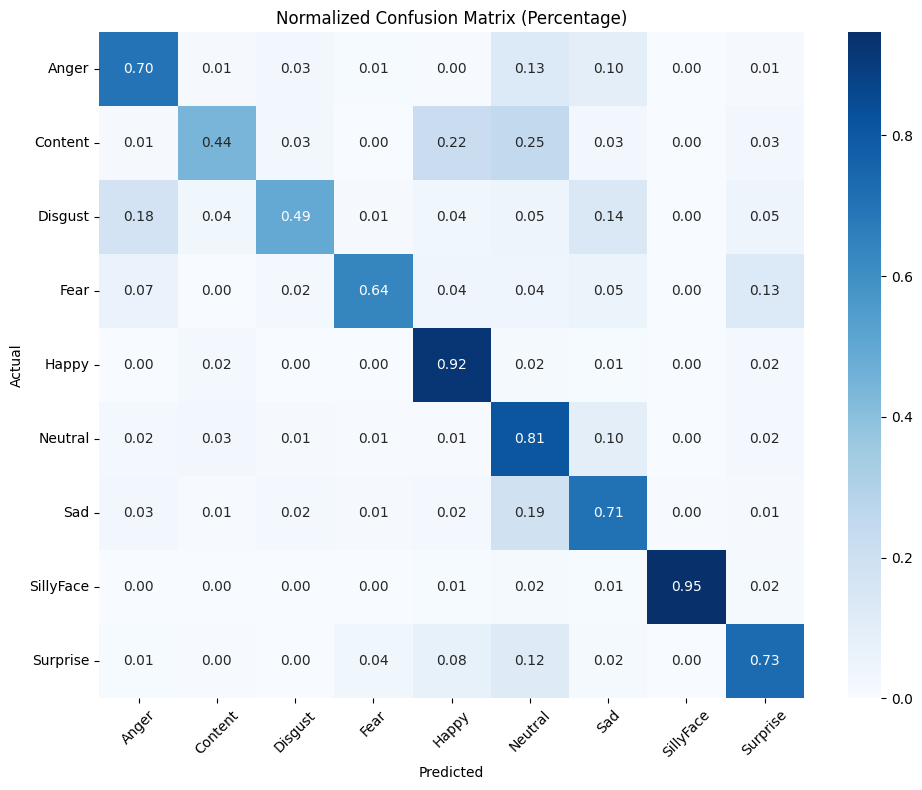

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Confusion Matrix (normalized)
cm = confusion_matrix(all_labels, all_preds)

# Normalize (row-wise → per true class)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plot
plt.figure(figsize=(10,8))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.2f',   # show decimals (0–1)
    cmap='Blues',
    xticklabels=test_data.classes,
    yticklabels=test_data.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Normalized Confusion Matrix (Percentage)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [19]:
from sklearn.metrics import classification_report

report = classification_report(
    all_labels,
    all_preds,
    target_names=test_data.classes,
    output_dict=True
)

print("\nClassification Report:")
print(f"{'':14} {'precision':>9} {'recall':>9} {'f1-score':>9} {'support':>9}\n")

# Print per-class rows
for class_name in test_data.classes:
    p = report[class_name]["precision"]
    r = report[class_name]["recall"]
    f1 = report[class_name]["f1-score"]
    s = int(report[class_name]["support"])

    print(f"{class_name:14} {p:9.2f} {r:9.2f} {f1:9.2f} {s:9d}")

# Print accuracy only
accuracy = report["accuracy"]
total_support = len(all_labels) 

print(f"\n{'accuracy':14} {'':9} {'':9} {accuracy:9.2f} {total_support:9d}")


Classification Report:
               precision    recall  f1-score   support

Anger               0.77      0.70      0.73       231
Content             0.50      0.44      0.47        77
Disgust             0.59      0.49      0.54        79
Fear                0.72      0.64      0.68        91
Happy               0.89      0.92      0.91       493
Neutral             0.69      0.81      0.74       501
Sad                 0.77      0.71      0.74       477
SillyFace           0.98      0.95      0.96       112
Surprise            0.76      0.73      0.74       223

accuracy                                0.77      2284


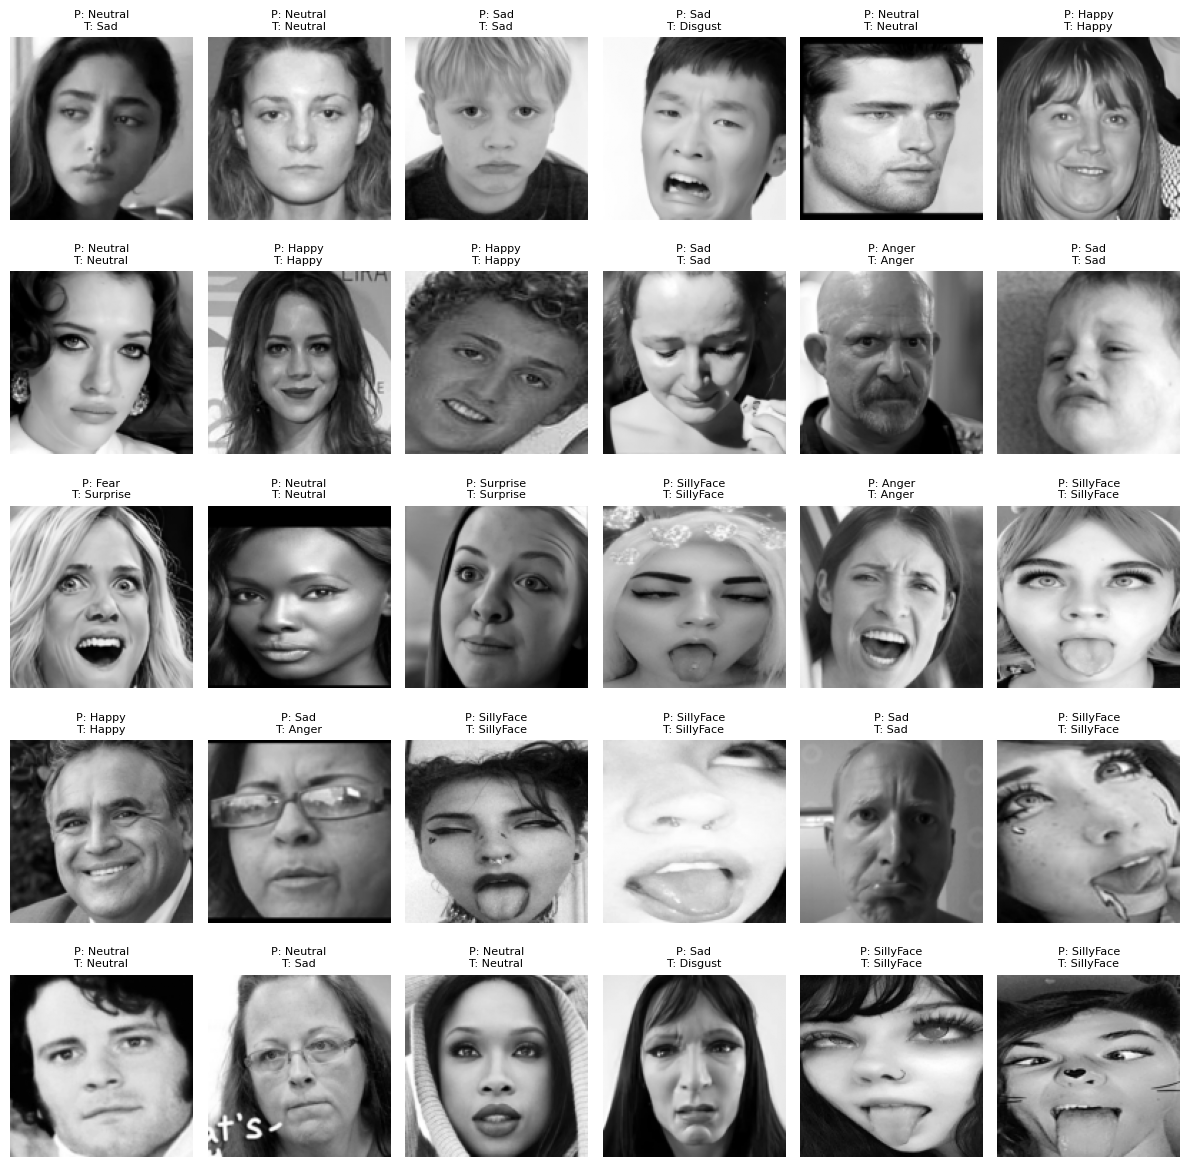

In [20]:
import random

# Class names
class_names = test_data.classes

# Load best model
model = models_dict[global_best_model_name]
model.load_state_dict(torch.load(f"models/{global_best_model_name}_best.pth"))
model = model.to(device)
model.eval()

# Pick 30 random samples
indices = random.sample(range(len(test_data)), 30)

plt.figure(figsize=(12,12))

for i, idx in enumerate(indices):
    img, label = test_data[idx]

    input_img = img.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_img)
        _, pred = torch.max(output, 1)

    pred_label = class_names[pred.item()]
    true_label = class_names[label]

    img_np = img.squeeze(0).cpu().numpy()

    plt.subplot(5,6,i+1)
    plt.imshow(img_np, cmap='gray')
    plt.title(f"P: {pred_label}\nT: {true_label}", fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [21]:
# Per-class accuracy

import numpy as np

num_classes = len(test_data.classes)

class_correct = [0] * num_classes
class_total = [0] * num_classes

best_model.eval()

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        y = y.to(device)

        outputs = best_model(x)
        _, preds = torch.max(outputs, 1)

        for i in range(len(y)):
            label = y[i].item()
            pred = preds[i].item()

            if label == pred:
                class_correct[label] += 1

            class_total[label] += 1

# Print results
print("\nPer-Class Accuracy:\n")

for i in range(num_classes):
    acc = class_correct[i] / class_total[i] if class_total[i] != 0 else 0
    print(f"{test_data.classes[i]}: {acc:.4f} ({class_correct[i]}/{class_total[i]})")


Per-Class Accuracy:

Anger: 0.7013 (162/231)
Content: 0.4416 (34/77)
Disgust: 0.4937 (39/79)
Fear: 0.6374 (58/91)
Happy: 0.9229 (455/493)
Neutral: 0.8064 (404/501)
Sad: 0.7086 (338/477)
SillyFace: 0.9464 (106/112)
Surprise: 0.7309 (163/223)


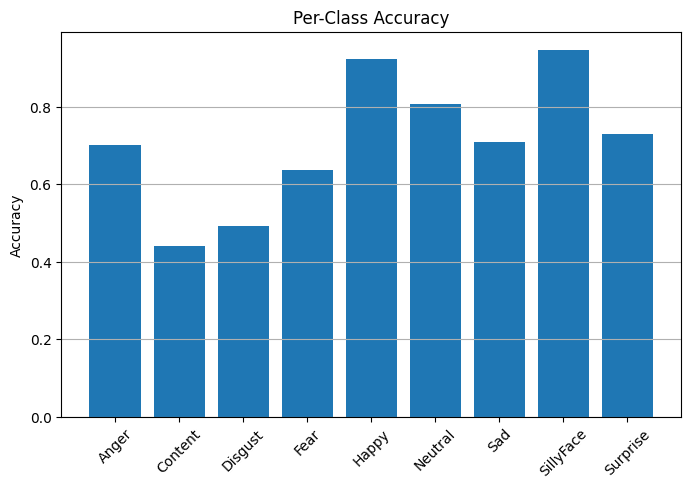

In [22]:
import matplotlib.pyplot as plt

class_acc = [
    class_correct[i] / class_total[i] if class_total[i] != 0 else 0
    for i in range(num_classes)
]

plt.figure(figsize=(8,5))
plt.bar(test_data.classes, class_acc)
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Per-Class Accuracy")
plt.grid(axis='y')
plt.show()